# Прогнозирование оттока клиентов банка

Проанализированы клиенты, обслуживающихся в многонациональном банке ABC. Цель данной работы — прогнозирование оттока клиентов.  

In [ ]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

import warnings
# Отключение предупреждений (warnings)
warnings.filterwarnings("ignore")

Содержание  
- Исследование данных
- Прогнозирование оттока
- Кластеризация

In [3]:
# импорт данных (с сайта kaggle.com)
df = pd.read_csv('Bank Customer Churn Prediction.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


Структура данных:  

- customer_id,   
- credit_score,   
- country,   
- gender,   
- age,  
- tenure,   
- balance,  
- products_number,   
- credit_card,   
- active_member,   
- estimated_salary,   
- churn 1, если клиент покинул банк за определенный период, или 0, если нет.

In [5]:
df.describe(include='all').round()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.0,10000.0,10000,10000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
unique,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,15690941.0,651.0,NaN,NaN,39.0,5.0,76486.0,2.0,1.0,1.0,100090.0,0.0
std,71936.0,97.0,NaN,NaN,10.0,3.0,62397.0,1.0,0.0,0.0,57510.0,0.0
min,15565701.0,350.0,NaN,NaN,18.0,0.0,0.0,1.0,0.0,0.0,12.0,0.0
25%,15628528.0,584.0,NaN,NaN,32.0,3.0,0.0,1.0,0.0,0.0,51002.0,0.0
50%,15690738.0,652.0,NaN,NaN,37.0,5.0,97199.0,1.0,1.0,1.0,100194.0,0.0
75%,15753234.0,718.0,NaN,NaN,44.0,7.0,127644.0,2.0,1.0,1.0,149388.0,0.0


In [6]:
df.duplicated().sum()

np.int64(0)

Пропусков в данных нет, отрицательных значений нет, дупликатов тоже нет. Но есть категориальные поля *country* и *gender*, которые необходимо предобработать, например, перевести в числовые категориии.

Сейчас удалим ненужное для моделей поле - *customer_id*, и исследуем данные.

In [7]:
df.drop(columns='customer_id', inplace=True)

## Исследование данных

In [8]:
df.churn.value_counts(normalize=True)

churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64

Есть смещение по целевому признаку (оттоку): 80% активные и 20% ушедшие - большой дисбаланс, который необходимо учитывать при оценке моделей.

<Axes: >

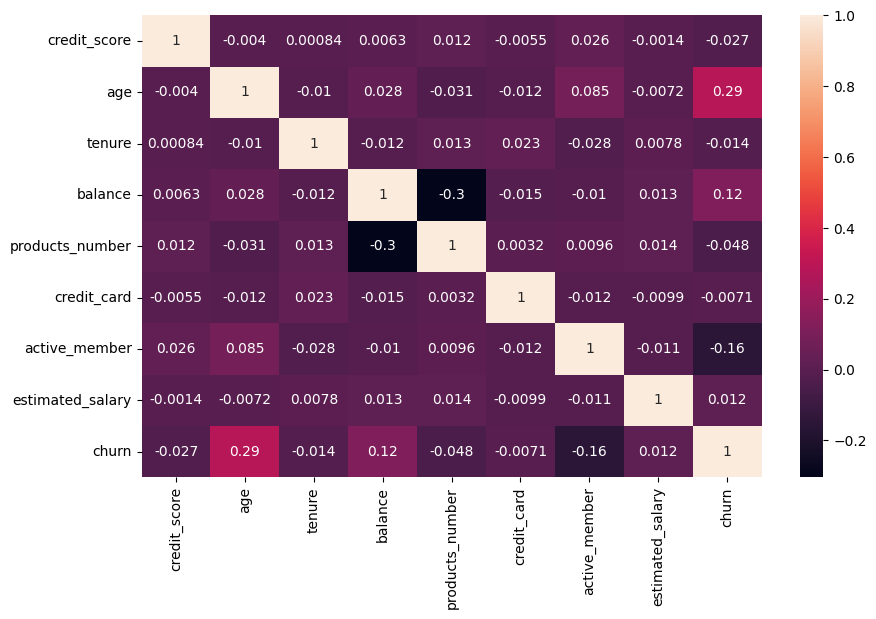

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=['country','gender']).corr(),annot=True)

Сильно скоррелированных признаков нет, но есть небольшая корреляция между *balance* и *products_number* и между возрастом и числом ушедших клиентов.

Посмотрим на распределение признаков по оттоку.

In [10]:
# выделим категориальные и не категориальные признаки
cat_col = [col for col in df.drop(columns='churn').columns if df[col].nunique() <= 11]
not_cat_col = [col for col in df.drop(columns='churn').columns if df[col].nunique() > 11]

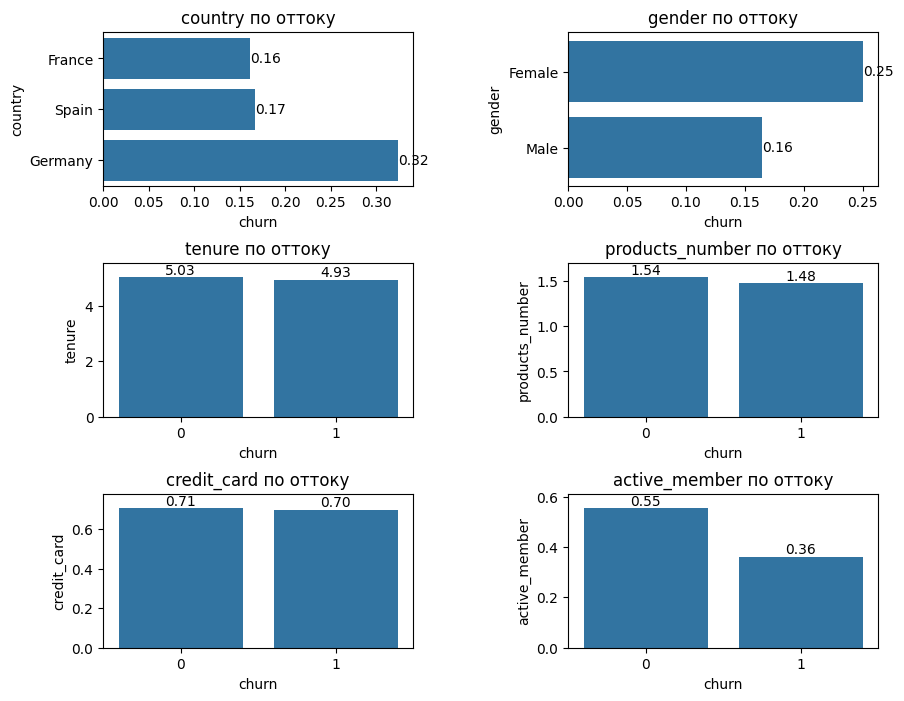

In [11]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    ax = sns.barplot(data=df, x='churn', y=col, ax=axes[i], errorbar=None,)
    ax.set_title(f'{col} по оттоку')
    bar_labels = [f'{v:.2f}' for v in ax.containers[0].datavalues]
    ax.bar_label(ax.containers[0], labels=bar_labels)
    y_lim = ax.get_ylim()
    ax.set_ylim(y_lim[0], y_lim[1]*1.05)

# убираем лишние пустые оси
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

Среди немцев больше доля оттока - 32%, в Испании и Франции - по 16-17%. Женщины чаще уходят: четверть из них ушли, среди мужчин таких 16%. 

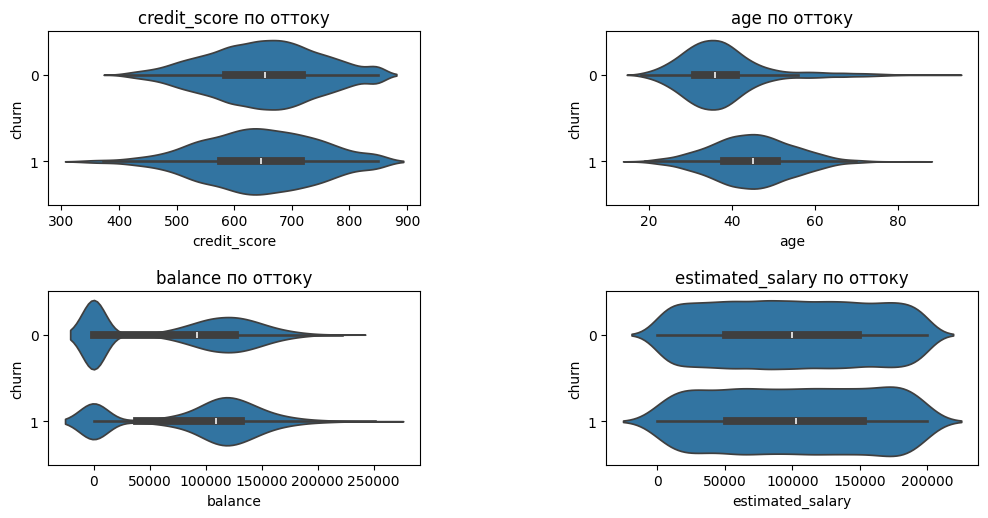

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(not_cat_col):
    ax = sns.violinplot(data=df, y='churn', x=col, orient='h', ax=axes[i])
    ax.set_title(f'{col} по оттоку')

# убираем лишние пустые оси
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

Средний возраст ушедиших клиентов больше, чем не ушедших. Средний *balance* также больше у ушедших клиентов, а среди не покинувших банк больше клиентов с нулевым балансом.

## ML прогнозирование оттока

Подготовим данные для моделей: преобразуем категориальные признаки в числовые, разделим данные на обучающую и тестовую выборку, учитывая дисбаланс по целевому признаку

In [13]:
le = LabelEncoder()
df_le = df.copy()
df_le['country'] = le.fit_transform(df_le.country)
df_le['gender'] = le.fit_transform(df_le.gender)

In [14]:
df_le.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df_le.drop(columns='churn'), df_le.churn,
    random_state=42, test_size=0.2, stratify=df_le.churn
)

In [16]:
def print_metrics(test, predict_value):
    '''Функция вывода основных метрик'''
    # метрики точности и полноты
    print(classification_report(test, predict_value))
    #print('F1 мера на обучающем наьоре', round(f1_score()))
    print('roc_auc', round(roc_auc_score(test, predict_value), 3))
    # матрица разброса для оценки точности
    cm = confusion_matrix(test, predict_value)
    plt.figure(figsize=(3,2))
    sns.heatmap(cm, annot=True, fmt='', cmap='Blues')
    plt.xlabel('прогноз')
    plt.ylabel('факт')
    plt.show()

Построим прогноз с помощью дерева решений с подбором гиперпараметров по сетке и по лучшей модели построим прогноз

In [17]:
%%time
# дерево решений
dt = DecisionTreeClassifier(random_state=42)
dt_cv = GridSearchCV(dt, {'max_depth': [10,100,500],
                        'min_samples_leaf': [1,40,100],
                        'criterion': ['gini', 'enthropy'],
                        'max_features': [3,7,None]},
                    cv=5, scoring='f1', n_jobs=-1)
dt_cv.fit(X_train, y_train)
print('лучшие параметры', dt_cv.best_params_)
print('F1', dt_cv.best_score_)

лучшие параметры {'criterion': 'gini', 'max_depth': 100, 'max_features': 7, 'min_samples_leaf': 40}
F1 0.5557135074364312
CPU times: total: 469 ms
Wall time: 3.33 s


              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1593
           1       0.70      0.44      0.54       407

    accuracy                           0.85      2000
   macro avg       0.79      0.70      0.73      2000
weighted avg       0.84      0.85      0.83      2000

roc_auc 0.698


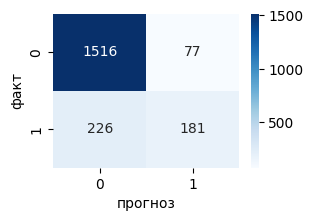

In [18]:
dt_best = dt_cv.best_estimator_
dt_best.fit(X_train, y_train)
dt_pred = dt_best.predict(X_test)
print_metrics(y_test, dt_pred)

Модель больше чем в половине случаев ошибается при прогнозе оттока. F1 мера - 0,54, а *recall* - доля правильно спрогнозированного класса 1 - всего 0,44.

Построим прогноз с помощью модели случайного леса

In [19]:
%%time
# случайный лес
rf = RandomForestClassifier(random_state=42)
grid_params = {'n_estimators':[100,150,200],
                'max_depth': [5,10,None],
                'min_samples_split': [20,25,30],
                'max_features': [6,8,None]}
rf_cv = GridSearchCV(rf, grid_params,
                    cv=5, scoring='f1', n_jobs=-1)
rf_cv.fit(X_train, y_train)
print('лучшие параметры', rf_cv.best_params_)
print('best_score', rf_cv.best_score_)

лучшие параметры {'max_depth': None, 'max_features': 6, 'min_samples_split': 25, 'n_estimators': 200}
best_score 0.5780183353243663
CPU times: total: 3.48 s
Wall time: 1min 30s


              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000

roc_auc 0.709


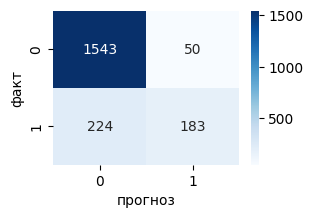

In [20]:
rf_best = rf_cv.best_estimator_
rf_best.fit(X_train, y_train)
rf_pred = rf_best.predict(X_test)
print_metrics(y_test, rf_pred)

Прогноз оттока также плохо прогнозируется - *recall* всего 0,45.

Попробуем применить градиентный бустинг.

In [21]:
df_le[cat_col] = df_le[cat_col].astype('category')

In [ ]:
# градиентный бустинг
lgbm = LGBMClassifier(random_state=42,objective='binary')
lgbm_cv = GridSearchCV(lgbm, {'n_estimators':[50,100,25],
                            'max_depth': [2,3,5, None],
                            'learning_rate': [0.12,0.15,0.8],
                            'num_leaves': [10,20,30]
                            }, 
                        n_jobs=-1,scoring='f1',verbose=False)
lgbm_cv.fit(X_train, y_train)
print('лучшие параметры', lgbm_cv.best_params_)
print('best_score', lgbm_cv.best_score_)

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
лучшие параметры {'learning_rate': 0.15, 'max_depth': None, 'n_estimators': 50, 'num_leaves': 20}
best_score 0.5962494631811867


[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

roc_auc 0.725


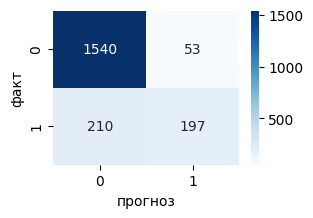

In [23]:
lgbm_best = lgbm_cv.best_estimator_
lgbm_best.fit(X_train, y_train)
lgbm_pred = lgbm_best.predict(X_test)
print_metrics(y_test, lgbm_pred)

Градиентный бустинг немного лучше, чем случайный лес: *recall* поднялся до 0,48.  
Попробуем еще одну модель градиентного бустинга - CatBoostClassifier, которая настроена для работы с категориальными признаками, а таких у нас 6 из 10.

In [ ]:
data = Pool(data=X_train, label=y_train, cat_features=[1,2,4,6,7,8])

In [25]:
cbc = CatBoostClassifier(random_state=42,cat_features=[1,2,4,6,7,8],
                        thread_count=-1, loss_function='Logloss',
                        verbose=False, eval_metric='F1')
cbc_cv = cbc.grid_search(param_grid={
                            'depth': [6,8,10],
                            'learning_rate': [0.01,0.05,0.1],
                            'iterations': [50,100,200],
                            }, 
                        X=X_train, y=y_train,
                        verbose=False, cv=3,plot=True)

print('лучшие параметры', cbc_cv['params'])

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))


bestTest = 0.4435643564
bestIteration = 0


bestTest = 0.5615384615
bestIteration = 47


bestTest = 0.5814814815
bestIteration = 45


bestTest = 0.52
bestIteration = 81


bestTest = 0.5735294118
bestIteration = 99


bestTest = 0.5992907801
bestIteration = 90


bestTest = 0.5610687023
bestIteration = 198


bestTest = 0.6010544815
bestIteration = 192


bestTest = 0.6273830156
bestIteration = 119


bestTest = 0.458677686
bestIteration = 48


bestTest = 0.569259962
bestIteration = 30


bestTest = 0.5827338129
bestIteration = 48


bestTest = 0.52734375
bestIteration = 75


bestTest = 0.5837837838
bestIteration = 94


bestTest = 0.6027874564
bestIteration = 92


bestTest = 0.5616698292
bestIteration = 145


bestTest = 0.6013986014
bestIteration = 175


bestTest = 0.6204506066
bestIteration = 146


bestTest = 0.4444444444
bestIteration = 0


bestTest = 0.573556797
bestIteration = 46


bestTest = 0.5884476534
bestIteration = 37


bestTest = 0.5408560311
bestIteration = 99


bestTest = 0.58181

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

roc_auc 0.725


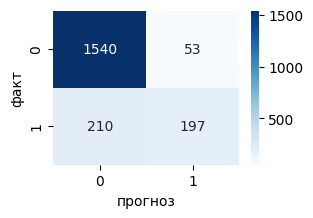

In [26]:
cbc_best = CatBoostClassifier(random_state=42,cat_features=[1,2,4,6,7,8],
                        thread_count=-1, loss_function='Logloss',
                        verbose=False, eval_metric='F1',
                        depth=6, learning_rate=0.1, iterations=200)
cbc_best.fit(X_train, y_train)
cbc_best_pred = lgbm_best.predict(X_test)
print_metrics(y_test, cbc_best_pred)

Метрики - *recall* - 0,48, *f1* мера - 0,6 - остались такими же. Дополнительная настройка гиперпараметров может улучшить прогноз, но не намного, существенного улучшения ожидать не стоит. Вероятно, добавление признаков, которые отражают поведение пользователей и влияют на отток, поможет улучшить прогноз, потому что моделям сейчас не хватает информации в поиске закономерностей оттока.

## Кластеризация

Попробуем кластеризировать пользователей и посмотрим разницу в кластерах.  

Сначала стандартизируем.

In [27]:
sc = StandardScaler()

X_cluster = sc.fit_transform(df_le.drop(columns='churn'))
X_cluster[:5]

array([[-0.32622142, -0.90188624, -1.09598752,  0.29351742, -1.04175968,
        -1.22584767, -0.91158349,  0.64609167,  0.97024255,  0.02188649],
       [-0.44003595,  1.51506738, -1.09598752,  0.19816383, -1.38753759,
         0.11735002, -0.91158349, -1.54776799,  0.97024255,  0.21653375],
       [-1.53679418, -0.90188624, -1.09598752,  0.29351742,  1.03290776,
         1.33305335,  2.52705662,  0.64609167, -1.03067011,  0.2406869 ],
       [ 0.50152063, -0.90188624, -1.09598752,  0.00745665, -1.38753759,
        -1.22584767,  0.80773656, -1.54776799, -1.03067011, -0.10891792],
       [ 2.06388377,  1.51506738, -1.09598752,  0.38887101, -1.04175968,
         0.7857279 , -0.91158349,  0.64609167,  0.97024255, -0.36527578]])

Для кластеризации воспользуемся алгоритмом DBSCAN. Для него необходимо подобрать 2 гиперпараметра: min_samples - минимальное число точек в окрестности (обычно число признаков+1 - у нас это 11) и eps - радиус этой окрестности, его определим из графика расстояний до k-ближайших соседей.

In [ ]:
near = NearestNeighbors(n_neighbors=10)
near_fit = near.fit(X_cluster)
dist, ind = near_fit.kneighbors(X_cluster)

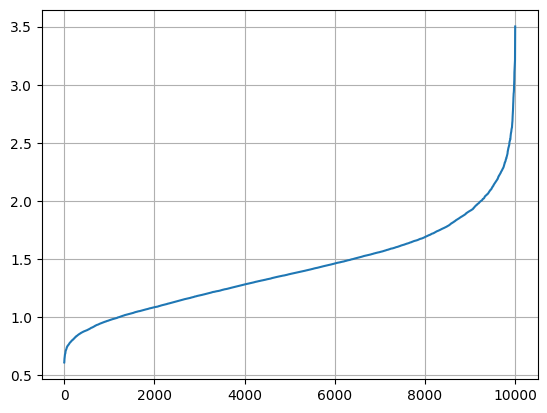

In [29]:
plt.plot(sorted(dist[:, -1]))
plt.grid()
plt.show()

Для eps выберем значение 2, после которого начинается резкий раст графика.

In [ ]:
dbscan = DBSCAN(eps=2, min_samples=10)
df_labels = dbscan.fit_predict(X_cluster)

In [31]:
pd.Series(df_labels).value_counts()

 4    2004
 3    1830
 7    1582
 0    1567
 5     830
 6     733
 1     662
 2     632
-1     160
Name: count, dtype: int64

При eps=2 и min_samples=10 поличили 8 кластеров и один небольшой кластер, включающий точки, которые не были отнесены ни к одному из основных. Дальнейшее увеличение eps ведет к резкому сокращению числа кластеров, тогда как его снижение - к их рост. Изменение параметра min_samples не оказывает заметного влияения на количество кластеров.  

Посмотрим на различие кластеров в разрезе клиентов с оттоком

In [32]:
df['cluster'] = df_labels

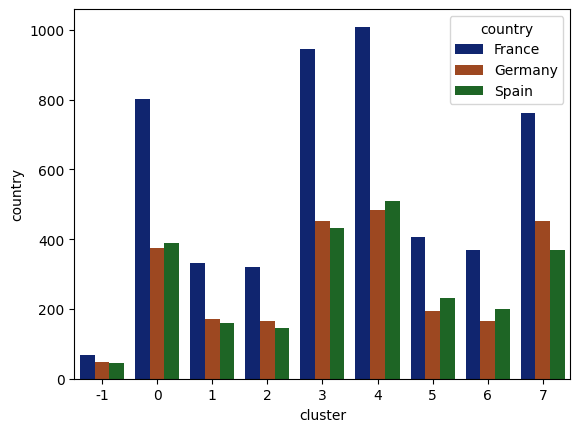

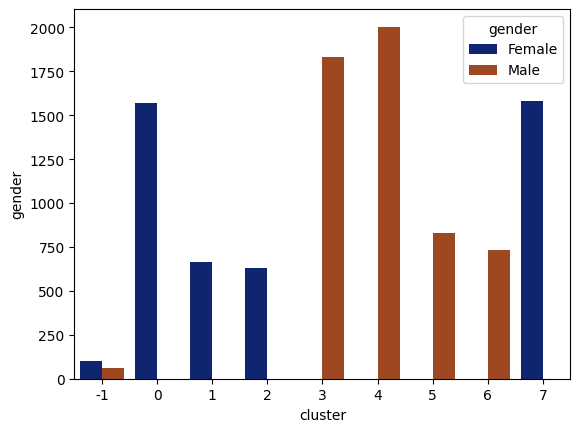

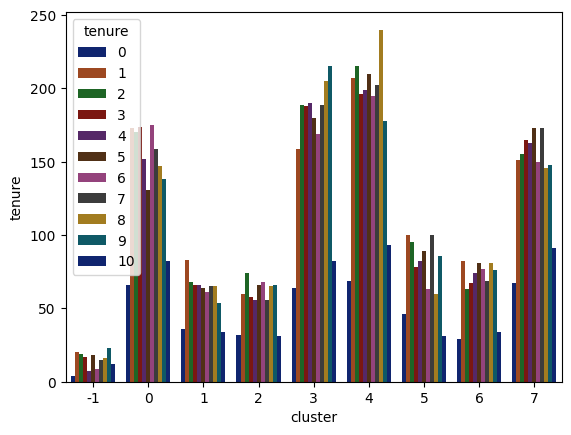

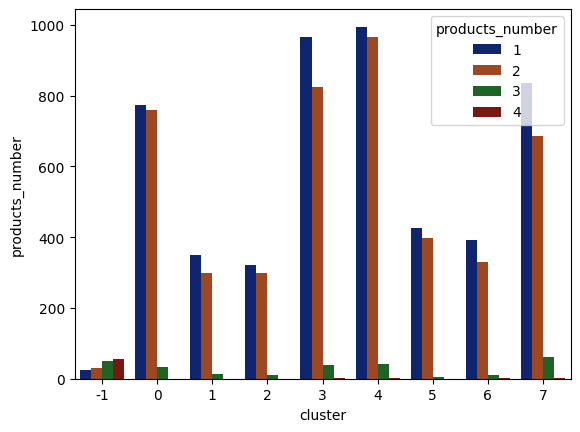

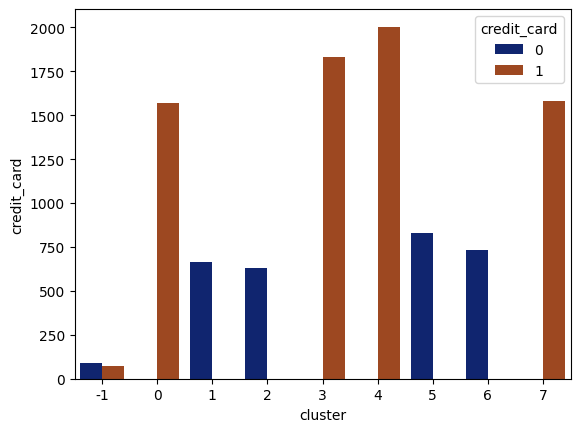

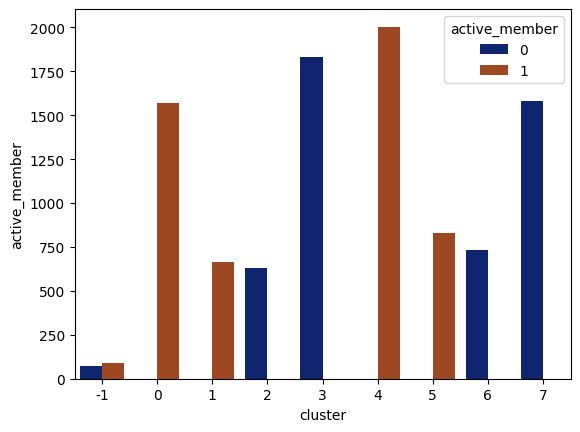

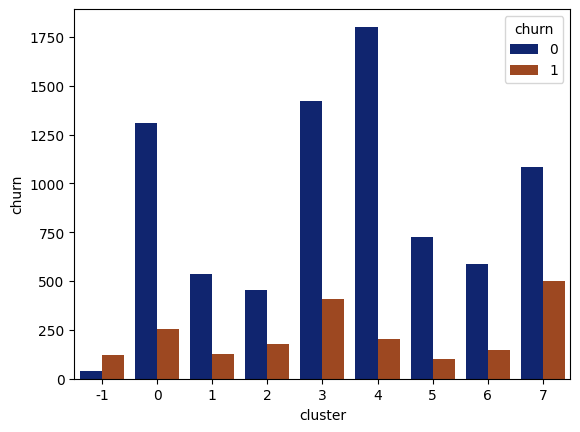

In [33]:
for i in df[cat_col+['churn']]:
    sns.barplot(data=df.groupby(['cluster', i], as_index=False).size(), 
                x='cluster', y='size', hue=i, palette='dark')
    plt.ylabel(i)
    plt.show()

Заметно большое число ушедших пользователей в кластерах 3 и 7 - это не активные клиенты с наличием кредитной карты. В целом кластеры сегментированы по полу, наличию кредитной карты и признаку *active_member*. Например, в кластере 7 наблюдается наибольшее количество ушедших клиентов и самая высокая их доля (почти треть кластера): это женщины, которые не являются *active_member*, но имеющую кредитную карту.